# Digital Watermarking Analysis

## 1. Install Dependencies
Run this cell if you haven't installed the required libraries yet.
**NOTE** :  If you still get errors in the notebook, it might be because of your environment. You can try running this command in your terminal/command prompt to be sure

In [2]:
!pip install opencv-python numpy matplotlib scipy

'pip' is not recognized as an internal or external command,
operable program or batch file.


### 2. Utilities for LSB Watermarking and Manual JPEG Simulation

This section contains all the necessary functions for embedding and extracting watermarks, calculating metrics (PSNR, BER), and simulating JPEG compression using DCT/IDCT.

**Wajib dijalankan sebelum lanjut ke Eksperimen.**

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.fftpack import dct, idct

BIT_POSITION = 3  # Kita gunakan bit ke-3 (0, 1, 2, [3], 4, 5, 6, 7) agar lebih tahan kompresi

def load_image(path, mode='gray'):
    """Baca gambar dari disk. Default diubah ke 'gray' demi ketahanan JPEG."""
    if mode == 'gray':
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    else:
        img = cv2.imread(path, cv2.IMREAD_COLOR)

    if img is None:
        raise FileNotFoundError(f"Gambar tidak ditemukan: {path}")
    return img

def load_watermark(path, size):
    """Baca watermark, konversi ke biner (0 dan 1), resize ke ukuran tertentu."""
    wm = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if wm is None:
        raise FileNotFoundError(f"Watermark tidak ditemukan: {path}")

    wm = cv2.resize(wm, size, interpolation=cv2.INTER_NEAREST)
    _, wm_binary = cv2.threshold(wm, 127, 1, cv2.THRESH_BINARY)
    return wm_binary

def _get_location(location, img_h, img_w, wm_h, wm_w):
    if location == 'top-left': return 0, 0
    elif location == 'center': return (img_h - wm_h) // 2, (img_w - wm_w) // 2
    elif location == 'bottom-right': return img_h - wm_h, img_w - wm_w
    elif location == 'top-right': return 0, img_w - wm_w
    elif location == 'bottom-left': return img_h - wm_h, 0
    return 0, 0

def embed_lsb(image, watermark_binary, location='center'):
    """
    [OPTIMIZED] Menyisipkan bit watermark dengan sistem redundansi blok.
    Setiap 1 bit watermark akan disebar ke blok piksel berukuran 2x2.
    """
    img = image.copy()
    wm_h, wm_w = watermark_binary.shape
    img_h, img_w = img.shape[:2]
    
    block_size = 3
    row_start, col_start = _get_location(location, img_h, img_w, wm_h * block_size, wm_w * block_size)
    
    mask = ~(1 << BIT_POSITION) & 0xFF

    for r in range(wm_h):
        for c in range(wm_w):
            bit = int(watermark_binary[r, c])
            
            r_img = row_start + (r * block_size)
            c_img = col_start + (c * block_size)
            
            if r_img + block_size <= img_h and c_img + block_size <= img_w:
                if len(img.shape) == 3:
                    region = img[r_img:r_img+block_size, c_img:c_img+block_size, 1]
                    img[r_img:r_img+block_size, c_img:c_img+block_size, 1] = (region & mask) | (bit << BIT_POSITION)
                else:
                    region = img[r_img:r_img+block_size, c_img:c_img+block_size]
                    img[r_img:r_img+block_size, c_img:c_img+block_size] = (region & mask) | (bit << BIT_POSITION)
                    
    return img

def extract_lsb(watermarked_image, wm_size, location='center'):
    """
    [OPTIMIZED] Mengekstrak bit watermark menggunakan sistem Voting (Suara Terbanyak)
    dari blok piksel 2x2 untuk mengoreksi error akibat kompresi JPEG.
    """
    img = watermarked_image.copy()
    wm_w, wm_h = wm_size  # Disamakan dengan input tuple (64, 64) -> w=64, h=64
    img_h, img_w = img.shape[:2]
    
    block_size = 3
    row_start, col_start = _get_location(location, img_h, img_w, wm_h * block_size, wm_w * block_size)
    
    extracted = np.zeros((wm_h, wm_w), dtype=np.uint8)

    for r in range(wm_h):
        for c in range(wm_w):
            r_img = row_start + (r * block_size)
            c_img = col_start + (c * block_size)
            
            if r_img + block_size <= img_h and c_img + block_size <= img_w:
                if len(img.shape) == 3:
                    region = img[r_img:r_img+block_size, c_img:c_img+block_size, 1]
                else:
                    region = img[r_img:r_img+block_size, c_img:c_img+block_size]
                
                # Ambil bit dari seluruh piksel di dalam blok 2x2
                bits_in_block = (region >> BIT_POSITION) & 1
                
                # Sistem Voting: Jika rata-rata bit >= 0.5, isi dengan 1
                if np.mean(bits_in_block) >= 0.5:
                    extracted[r, c] = 1
                else:
                    extracted[r, c] = 0
                    
    return extracted

def calculate_psnr(original, compressed):
    original = original.astype(np.float64)
    compressed = compressed.astype(np.float64)
    mse = np.mean((original - compressed) ** 2)
    if mse == 0: return float('inf')
    return round(20 * np.log10(255.0 / np.sqrt(mse)), 2)

def calculate_ber(original_wm, extracted_wm):
    min_h = min(original_wm.shape[0], extracted_wm.shape[0])
    min_w = min(original_wm.shape[1], extracted_wm.shape[1])
    orig = original_wm[:min_h, :min_w]
    extr = extracted_wm[:min_h, :min_w]
    return round(np.sum(orig != extr) / orig.size, 4)

# Standard JPEG Luminance Quantization Table
Q_TABLE = np.array([
    [16, 11, 10, 16, 24, 40, 51, 61],
    [12, 12, 14, 19, 26, 58, 60, 55],
    [14, 13, 16, 24, 40, 57, 69, 56],
    [14, 17, 22, 29, 51, 87, 80, 62],
    [18, 22, 37, 56, 68, 109, 103, 77],
    [24, 35, 55, 64, 81, 104, 113, 92],
    [49, 64, 78, 87, 103, 121, 120, 101],
    [72, 92, 95, 98, 112, 100, 103, 99]
], dtype=np.float32)

def dct2(a):
    return dct(dct(a.T, norm='ortho').T, norm='ortho')

def idct2(a):
    return idct(idct(a.T, norm='ortho').T, norm='ortho')

def apply_manual_jpeg(img, quality):
    """
    Simulasi kompresi JPEG secara manual menggunakan DCT dan Kuantisasi.
    """
    # Menghitung skala kuantisasi berdasarkan Quality Factor
    if quality < 50:
        s = 5000 / quality
    else:
        s = 200 - 2 * quality
    
    q_scaled = np.floor((s * Q_TABLE + 50) / 100)
    q_scaled[q_scaled < 1] = 1
    q_scaled[q_scaled > 255] = 255
    
    h, w = img.shape[:2]
    # Hanya ambil bagian yang kelipatan 8 agar tidak error saat blok 8x8
    h_new, w_new = (h // 8) * 8, (w // 8) * 8
    
    result = img.copy().astype(np.float32)
    
    for ch in range(img.shape[2] if len(img.shape) == 3 else 1):
        for i in range(0, h_new, 8):
            for j in range(0, w_new, 8):
                if len(img.shape) == 3:
                    block = result[i:i+8, j:j+8, ch] - 128
                    coeffs = dct2(block)
                    quantized = np.round(coeffs / q_scaled)
                    dequantized = quantized * q_scaled
                    result[i:i+8, j:j+8, ch] = idct2(dequantized) + 128
                else:
                    block = result[i:i+8, j:j+8] - 128
                    coeffs = dct2(block)
                    quantized = np.round(coeffs / q_scaled)
                    dequantized = quantized * q_scaled
                    result[i:i+8, j:j+8] = idct2(dequantized) + 128
                    
    return np.clip(result, 0, 255).astype(np.uint8)

def get_file_size_kb(path):
    return round(os.path.getsize(path) / 1024, 2)

def show_watermark_comparison(original_wm, extracted_wms, labels, title="Perbandingan Watermark"):
    n = len(extracted_wms) + 1
    fig, axes = plt.subplots(1, n, figsize=(2.8 * n, 3.5))
   
    axes[0].imshow(original_wm * 255, cmap='gray', vmin=0, vmax=255)
    axes[0].set_title("Original\nWatermark", fontsize=10, fontweight='bold')
    axes[0].axis('off')

    for i, (wm, label) in enumerate(zip(extracted_wms, labels)):
        axes[i + 1].imshow(wm * 255, cmap='gray', vmin=0, vmax=255)
        axes[i + 1].set_title(label, fontsize=9)
        axes[i + 1].axis('off')

    plt.suptitle(title, fontsize=12, fontweight='bold', y=1.05)
    plt.tight_layout()
    return fig

def plot_metrics_table(data_rows, columns, title="Tabel Evaluasi"):
    fig, ax = plt.subplots(figsize=(len(columns) * 1.8, len(data_rows) * 0.5 + 1.0))
    ax.axis('off')
    table = ax.table(cellText=data_rows, colLabels=columns, loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.4)

    for j in range(len(columns)):
        table[0, j].set_facecolor('#2c3e50')
        table[0, j].set_text_props(color='white', fontweight='bold')

    plt.title(title, fontsize=12, fontweight='bold', pad=10)
    plt.tight_layout()
    return fig

# Experiment 1: Pengaruh Quality Factor JPEG (Optimized Version)

Membuktikan grafik penurunan kualitas watermark seiring turunnya QF JPEG.

RUNNING: EKSPERIMEN 1 — Pengaruh Quality Factor JPEG (MANUAL DCT)
[VERIFIKASI] BER In-Memory Array: 0.0
✓ Fungsi dasar aman. Memulai proses kompresi JPEG MANUAL...

   QF |   PSNR Img |      BER |  Error Bits |  File Size | Status
---------------------------------------------------------------------------
  100 |      51.37 |   0.0078 |          31 | 509.49 KB  ✓ Sangat Baik
   90 |      47.48 |   0.0583 |         238 | 207.56 KB  ✓ Sangat Baik
   80 |      45.29 |   0.0864 |         353 |  149.6 KB  ✓ Masih Terbaca
   70 |      44.71 |   0.1152 |         471 |  139.3 KB  ✓ Masih Terbaca
   50 |      34.54 |   0.1582 |         647 | 110.71 KB  ✓ Masih Terbaca
   30 |      33.38 |   0.1743 |         713 |  64.87 KB  ✓ Masih Terbaca
   10 |      29.91 |   0.3384 |        1386 |  32.23 KB  ~ Rusak Sebagian

PROSES SELESAI! Tiga file visualisasi sukses disimpan di folder 'Hasil/'


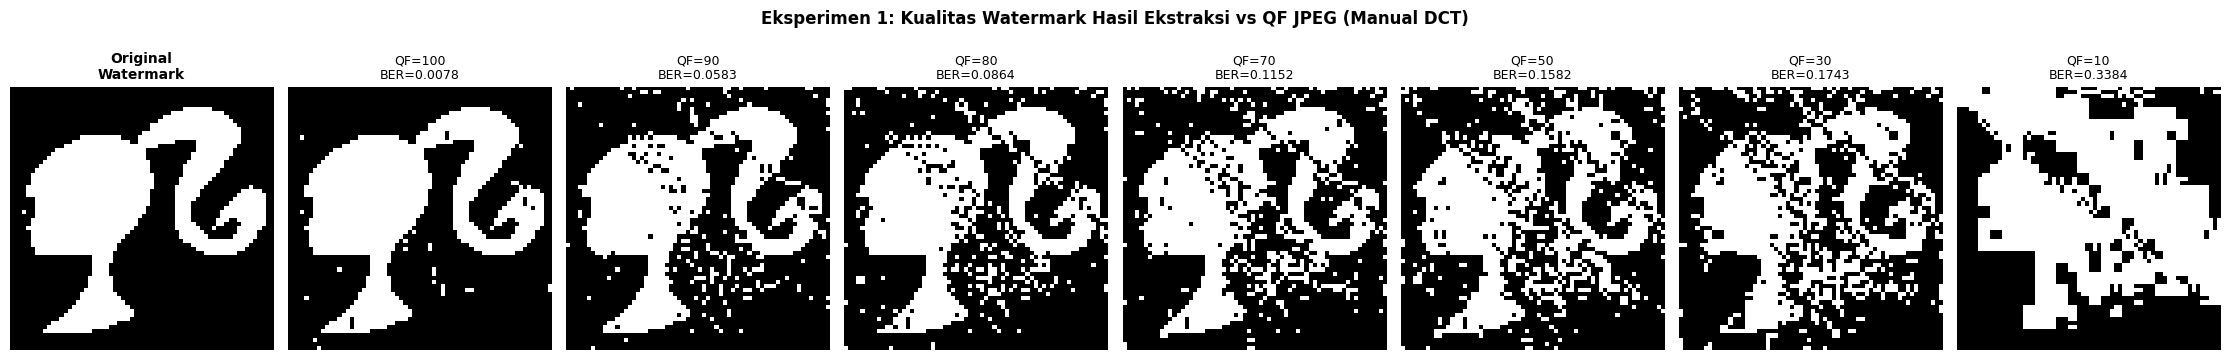

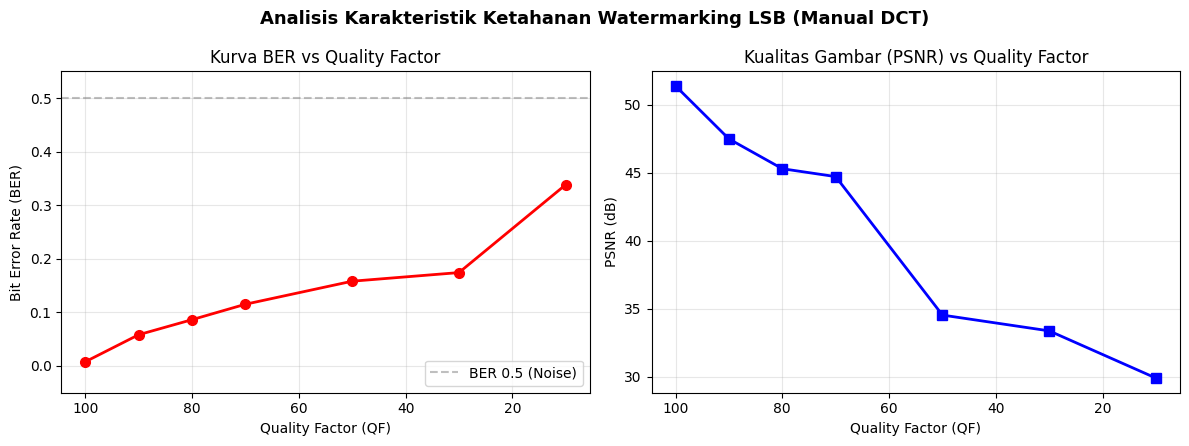

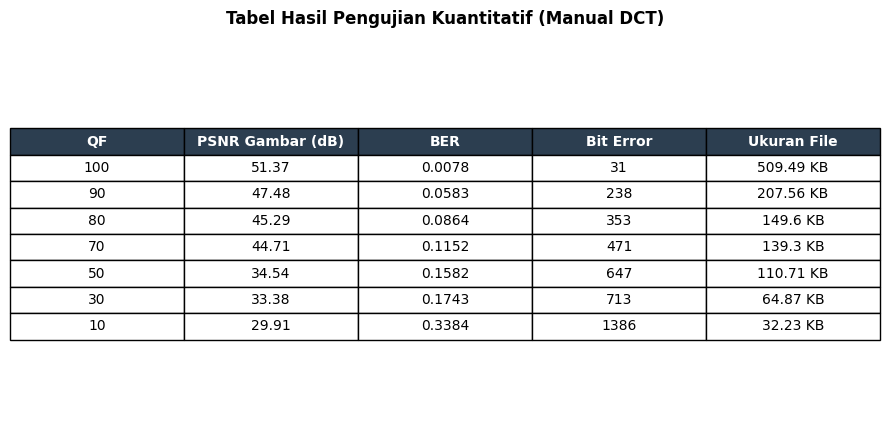

In [5]:
IMAGE_PATH     = "../data/face.jpeg"
WATERMARK_PATH = "../data/barbie_logo.png"
WM_SIZE        = (64, 64)
LOCATION       = 'top-left'
QUALITY_FACTORS = [100, 90, 80, 70, 50, 30, 10]

os.makedirs('../Hasil/watermarked', exist_ok=True)
os.makedirs('../Hasil/compressed', exist_ok=True)
os.makedirs('../Hasil/extracted/qf_experiment', exist_ok=True)

print("=" * 65)
print("RUNNING: EKSPERIMEN 1 — Pengaruh Quality Factor JPEG (MANUAL DCT)")
print("=" * 65)

# KUNCI UTAMA: Kita load sebagai COLOR untuk mempertahankan warna asli
image = load_image(IMAGE_PATH, mode='color')

# Load watermark
if os.path.exists(WATERMARK_PATH):
    watermark = load_watermark(WATERMARK_PATH, WM_SIZE)
else:
    print(f"Error: {WATERMARK_PATH} tidak ditemukan.")
    # Attempting to find it in direct path if relative fails
    if os.path.exists("data/barbie_logo.png"):
        WATERMARK_PATH = "data/barbie_logo.png"
        IMAGE_PATH = "data/face.jpeg"
        watermark = load_watermark(WATERMARK_PATH, WM_SIZE)
        image = load_image(IMAGE_PATH, mode='color')
    else:
        exit()

# --- EMBEDDING ---
watermarked = embed_lsb(image, watermark, location=LOCATION)
wm_png_path = '../Hasil/watermarked/watermarked_BASE.png'
cv2.imwrite(wm_png_path, watermarked)

# Verifikasi Awal (Wajib 0.0)
extracted_verify = extract_lsb(watermarked, WM_SIZE, location=LOCATION)
ber_verify = calculate_ber(watermark, extracted_verify)
print(f"[VERIFIKASI] BER In-Memory Array: {ber_verify}")
if ber_verify != 0.0:
    print("✗ PERINGATAN: Deteksi kegagalan fungsi dasar LSB!")
else:
    print("✓ Fungsi dasar aman. Memulai proses kompresi JPEG MANUAL...\n")

results = []
extracted_wms = []
qf_labels = []

print(f"{'QF':>5} | {'PSNR Img':>10} | {'BER':>8} | {'Error Bits':>11} | {'File Size':>10} | Status")
print("-" * 75)

for qf in QUALITY_FACTORS:
    compressed_path = f'../Hasil/compressed/compressed_qf{qf}.jpg'

    # KOMPRESI MANUAL: Menggunakan DCT dan Kuantisasi di blok 8x8
    compressed = apply_manual_jpeg(watermarked, quality=qf)

    # Simpan fisik ke disk (untuk estimasi ukuran file hasil kompresi)
    encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), qf]
    cv2.imwrite(compressed_path, compressed, encode_param)

    # Ekstraksi
    extracted = extract_lsb(compressed, WM_SIZE, location=LOCATION)

    # Metrik
    psnr_img   = calculate_psnr(watermarked, compressed)
    ber        = calculate_ber(watermark, extracted)
    error_bits = int(ber * WM_SIZE[0] * WM_SIZE[1])
    file_size  = get_file_size_kb(compressed_path)

    # Simpan hasil ekstraksi gambar
    extracted_img_path = f'../Hasil/extracted/qf_experiment/extracted_qf{qf}.png'
    cv2.imwrite(extracted_img_path, (extracted * 255).astype(np.uint8))

    results.append([qf, psnr_img, ber, error_bits, f"{file_size} KB"])
    extracted_wms.append(extracted)
    qf_labels.append(f"QF={qf}\nBER={ber}")

    if ber == 0.0: status = "✓ SEMPURNA"
    elif ber < 0.08: status = "✓ Sangat Baik"
    elif ber < 0.20: status = "✓ Masih Terbaca"
    elif ber < 0.38: status = "~ Rusak Sebagian"
    else: status = "✗ Hancur / Noise"

    print(f"{qf:>5} | {psnr_img:>10} | {ber:>8} | {error_bits:>11} | {file_size:>6} KB  {status}")

# --- VISUALISASI ---
fig1 = show_watermark_comparison(
    original_wm=watermark, extracted_wms=extracted_wms, labels=qf_labels,
    title="Eksperimen 1: Kualitas Watermark Hasil Ekstraksi vs QF JPEG (Manual DCT)"
)
fig1.savefig('../Hasil/exp1_watermark_extraction.png', dpi=150, bbox_inches='tight')

qf_vals   = [r[0] for r in results]
ber_vals  = [r[2] for r in results]
psnr_vals = [r[1] for r in results]

fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
fig2.suptitle('Analisis Karakteristik Ketahanan Watermarking LSB (Manual DCT)', fontsize=13, fontweight='bold')

ax1.plot(qf_vals, ber_vals, 'ro-', linewidth=2, markersize=7)
ax1.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='BER 0.5 (Noise)')
ax1.set_xlabel('Quality Factor (QF)')
ax1.set_ylabel('Bit Error Rate (BER)')
ax1.set_title('Kurva BER vs Quality Factor')
ax1.set_ylim(-0.05, 0.55)
ax1.invert_xaxis()
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.plot(qf_vals, psnr_vals, 'bs-', linewidth=2, markersize=7)
ax2.set_xlabel('Quality Factor (QF)')
ax2.set_ylabel('PSNR (dB)')
ax2.set_title('Kualitas Gambar (PSNR) vs Quality Factor')
ax2.invert_xaxis()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
fig2.savefig('../Hasil/exp1_ber_psnr_chart.png', dpi=150, bbox_inches='tight')

columns = ['QF', 'PSNR Gambar (dB)', 'BER', 'Bit Error', 'Ukuran File']
data_rows = [[str(r[0]), str(r[1]), str(r[2]), str(r[3]), r[4]] for r in results]
fig3 = plot_metrics_table(data_rows, columns, title="Tabel Hasil Pengujian Kuantitatif (Manual DCT)")
fig3.savefig('../Hasil/exp1_table.png', dpi=150, bbox_inches='tight')

print("\n" + "=" * 65)
print("PROSES SELESAI! Tiga file visualisasi sukses disimpan di folder 'Hasil/'")
print("=" * 65)
plt.show()